# Notebook 05.5

# Comparação Global dos Descritores

Nos notebooks anteriores foram implementados quatro descritores clássicos para representação de sequências peptídicas:

- AAC;
- AAL;
- CKSNAP;
- CKSAAGP.

Cada um deles captura aspectos distintos das sequências biológicas e produz conjuntos de atributos com diferentes níveis de complexidade.

Entretanto, antes da construção dos modelos de Aprendizado de Máquina, torna-se importante compreender as características de cada representação.

Neste notebook será realizada uma comparação quantitativa entre todos os descritores implementados.

## Objetivos

Ao final deste notebook será possível comparar os descritores segundo:

- dimensionalidade;

- variabilidade;

- distribuição da informação;

- correlação com a variável resposta;

- Informação Mútua;

- capacidade de representação (PCA);

- custo computacional;

- potencial de utilização em modelos supervisionados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
aac = pd.read_csv("../data/processed/aac_features.csv")
aal = pd.read_csv("../data/processed/aal_features.csv")
cksnap = pd.read_csv("../data/processed/cksnap_features.csv")
cksaagp = pd.read_csv("../data/processed/cksaagp_features.csv")

In [3]:
comparacao = pd.DataFrame({
    "AAC":[
        aac.shape[1]-1,
        aac.var(numeric_only=True).mean()
    ],
    "AAL":[
        aal.shape[1]-1,
        aal.var(numeric_only=True).mean()
    ],
    "CKSNAP":[
        cksnap.shape[1]-1,
        cksnap.var(numeric_only=True).mean()
    ],
    "CKSAAGP":[
        cksaagp.shape[1]-1,
        cksaagp.var(numeric_only=True).mean()
    ]
},

index=[
    "Número de atributos",
    "Variância média"
])

comparacao

,AAC,AAL,CKSNAP,CKSAAGP
Número de atributos,20.000000,400.000000,2400.000000,150.000000
Variância média,17.824459,0.933449,0.156186,2.483263


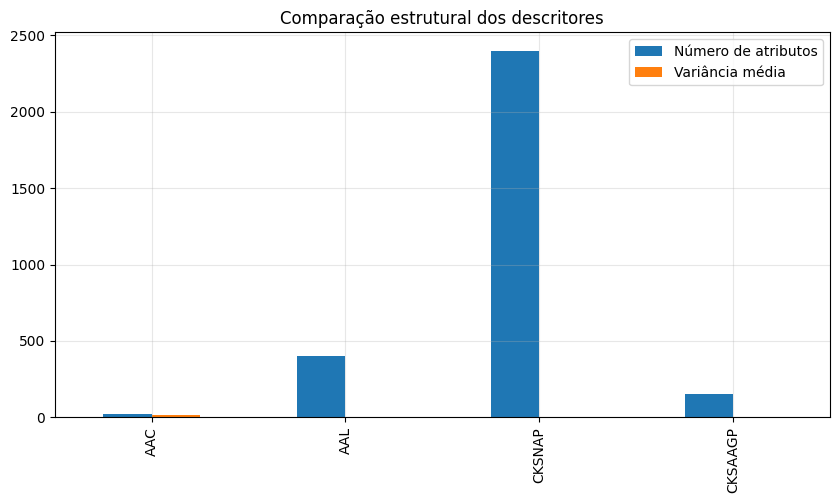

In [4]:
comparacao.T.plot.bar(
    figsize=(10,5)
)
plt.title("Comparação estrutural dos descritores")
plt.grid(alpha=0.3)
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca2(df):
    X = StandardScaler().fit_transform(
        df.drop(columns="best_docking_score")
    )
    pca = PCA(2)
    pca.fit(X)
    return pca.explained_variance_ratio_.sum()

In [7]:
pca_resultados = {
    "AAC":pca2(aac),
    "AAL":pca2(aal),
    "CKSNAP":pca2(cksnap),
    "CKSAAGP":pca2(cksaagp)
}

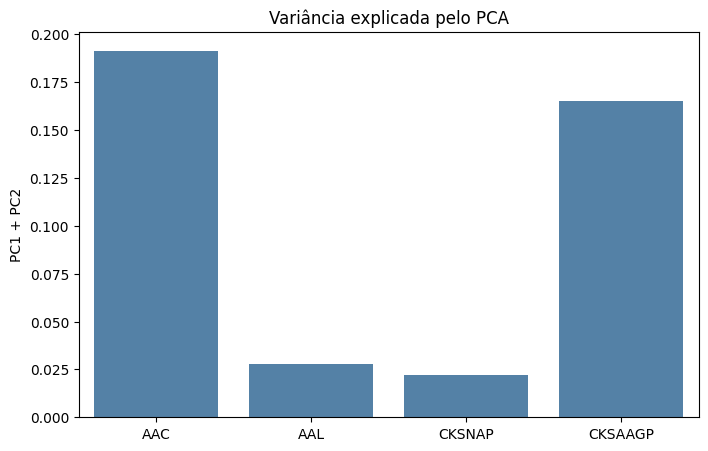

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=list(pca_resultados.keys()),
    y=list(pca_resultados.values()),
    color="steelblue"
)

plt.ylabel("PC1 + PC2")
plt.title("Variância explicada pelo PCA")
plt.show()

In [9]:
from sklearn.feature_selection import mutual_info_regression

def media_mi(df):
    X = df.drop(
        columns="best_docking_score"
    )
    y = df["best_docking_score"]
    mi = mutual_info_regression(
        X,
        y,
        random_state=42
    )

    return np.mean(mi)

In [10]:
mi = {
    "AAC":media_mi(aac),
    "AAL":media_mi(aal),
    "CKSNAP":media_mi(cksnap),
    "CKSAAGP":media_mi(cksaagp)
}

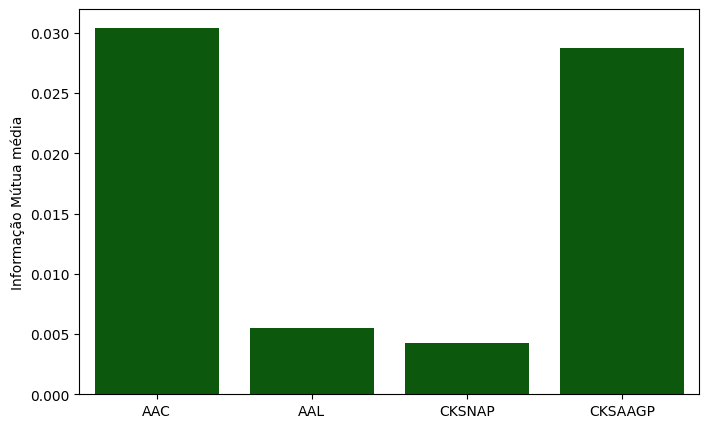

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=list(mi.keys()),
    y=list(mi.values()),
    color="darkgreen"
)
plt.ylabel("Informação Mútua média")
plt.show()

In [12]:
def media_corr(df):
    return (
        df.drop(
            columns="best_docking_score"
        )
        .corrwith(
            df["best_docking_score"]
        )
        .abs()
        .mean()
    )

In [13]:
corr = {
    "AAC":media_corr(aac),
    "AAL":media_corr(aal),
    "CKSNAP":media_corr(cksnap),
    "CKSAAGP":media_corr(cksaagp)
}

c:\Users\amaur\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\amaur\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


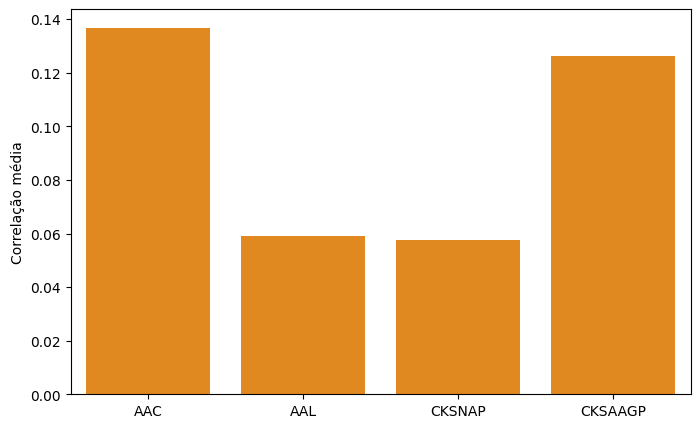

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=list(corr.keys()),
    y=list(corr.values()),
    color="darkorange"
)
plt.ylabel("Correlação média")
plt.show()

In [16]:
import time
tempos = []

for nome,funcao in [
    ("AAC",aac),
    ("AAL",aal),
    ("CKSNAP",cksnap),
    ("CKSAAGP",cksaagp)
]:
    inicio=time.perf_counter()
    _=funcao.describe()
    fim=time.perf_counter()
    tempos.append(
        fim-inicio
    )

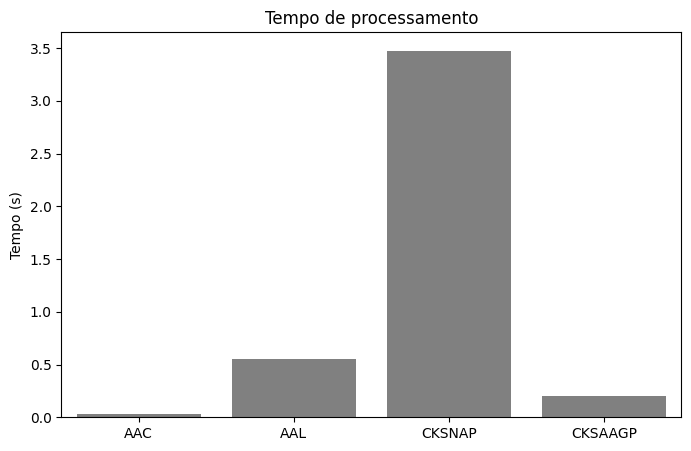

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=[
        "AAC",
        "AAL",
        "CKSNAP",
        "CKSAAGP"
    ],
    y=tempos,
    color="gray"
)

plt.ylabel("Tempo (s)")
plt.title("Tempo de processamento")
plt.show()

In [18]:
ranking = pd.DataFrame({

    "Dimensionalidade":[
        20,
        400,
        2400,
        150
    ],

    "PCA":[
        pca_resultados["AAC"],
        pca_resultados["AAL"],
        pca_resultados["CKSNAP"],
        pca_resultados["CKSAAGP"]
    ],

    "MI":[
        mi["AAC"],
        mi["AAL"],
        mi["CKSNAP"],
        mi["CKSAAGP"]
    ],

    "Correlação":[
        corr["AAC"],
        corr["AAL"],
        corr["CKSNAP"],
        corr["CKSAAGP"]
    ]
},

index=[
    "AAC",
    "AAL",
    "CKSNAP",
    "CKSAAGP"
])

In [21]:
from sklearn.preprocessing import MinMaxScaler

ranking_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(ranking),
    columns=ranking.columns,
    index=ranking.index
)
ranking_norm

,Dimensionalidade,PCA,MI,Correlação
AAC,0.000000,1.000000,1.000000,1.000000
AAL,0.159664,0.032110,0.048438,0.019012
CKSNAP,1.000000,0.000000,0.000000,0.000000
CKSAAGP,0.054622,0.844111,0.935965,0.867920


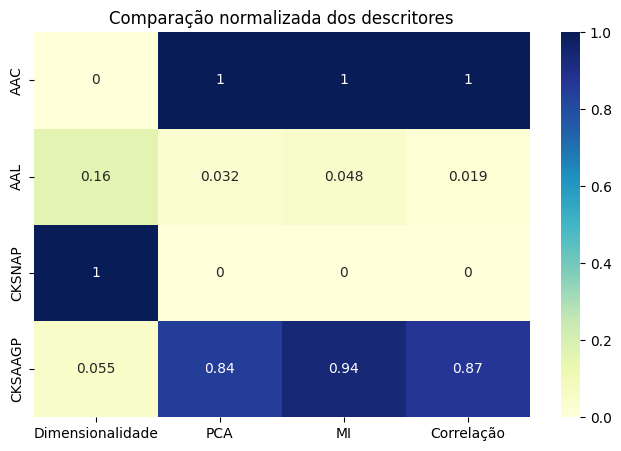

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    ranking_norm,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Comparação normalizada dos descritores"
)

plt.show()